<a href="https://colab.research.google.com/github/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes/blob/dataset-2-experiment-1/dataset_2_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
#1 imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc,
    roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

print("imports successfully loaded")

imports successfully loaded


In [10]:
!git clone https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git
%cd Predicting-Type-2-Diabetes


Cloning into 'Predicting-Type-2-Diabetes'...
remote: Enumerating objects: 360, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 360 (delta 51), reused 15 (delta 15), pack-reused 256 (from 4)
Receiving objects: 100% (360/360), 9.88 MiB | 16.70 MiB/s, done.
Resolving deltas: 100% (128/128), done.
/content/Predicting-Type-2-Diabetes/Predicting-Type-2-Diabetes/Predicting-Type-2-Diabetes/Predicting-Type-2-Diabetes/Predicting-Type-2-Diabetes


In [14]:
#load datas
path = "data/preprocessed/diabetes_prediction_dataset_preprocessed/"

X_train = pd.read_parquet(f"{path}X_train_scaled.parquet")
X_test  = pd.read_parquet(f"{path}X_test_scaled.parquet")
y_train = pd.read_parquet(f"{path}y_train.parquet").squeeze()
y_test  = pd.read_parquet(f"{path}y_test.parquet").squeeze()

print("-" * 50)
print(" Experiment 1: Raw Imbalanced Data Loaded")
print("-" * 50)
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train balance (Imbalanced): \n{y_train.value_counts(normalize=True) * 100}")

--------------------------------------------------
 Experiment 1: Raw Imbalanced Data Loaded
--------------------------------------------------
  X_train shape: (76916, 15)
  y_train balance (Imbalanced): 
diabetes
0    91.177388
1     8.822612
Name: proportion, dtype: float64


In [17]:
#model training
print("-" * 50)
print(" Training Models — Experiment 1 (Raw Baseline)")
print("-" * 50)

#Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("  Logistic Regression    — done")

#LightGBM
lgbm = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm.fit(X_train, y_train)
print("  LightGBM               — done")

#XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
print("  XGBoost                — done")

print("\nAll baseline models trained successfully.")

--------------------------------------------------
 Training Models — Experiment 1 (Raw Baseline)
--------------------------------------------------
  Logistic Regression    — done
  LightGBM               — done
  XGBoost                — done

All baseline models trained successfully.


In [23]:
#summary metric table
from IPython.display import display

models = {
    "Logistic Regression": lr,
    "LightGBM": lgbm,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_pred_prob)
    })

results_df = pd.DataFrame(results)

print("-" * 55)
print(" Experiment 1 - Baseline Model Comparison (Raw Data)")
print("-" * 55)

display(results_df.round(4))

-------------------------------------------------------
 Experiment 1 - Baseline Model Comparison (Raw Data)
-------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Logistic Regression,0.9596,0.8685,0.6386,0.7360,0.9599
1,LightGBM,0.9710,0.9695,0.6934,0.8085,0.9770
2,XGBoost,0.9702,0.9539,0.6958,0.8046,0.9756


In [24]:
#prediction and probabilities
model_preds = {}

for name, model in models.items():
    #hard predictions (for Accuracy, Precision, Recall, F1)
    y_pred = model.predict(X_test)

    #probability predictions (for AUC-ROC and ROC Curves)
    y_prob = model.predict_proba(X_test)[:, 1]

    model_preds[name] = {'y_pred': y_pred, 'y_prob': y_prob}

print("Predictions and Probabilities generated for all baseline models.")

Predictions and Probabilities generated for all baseline models.


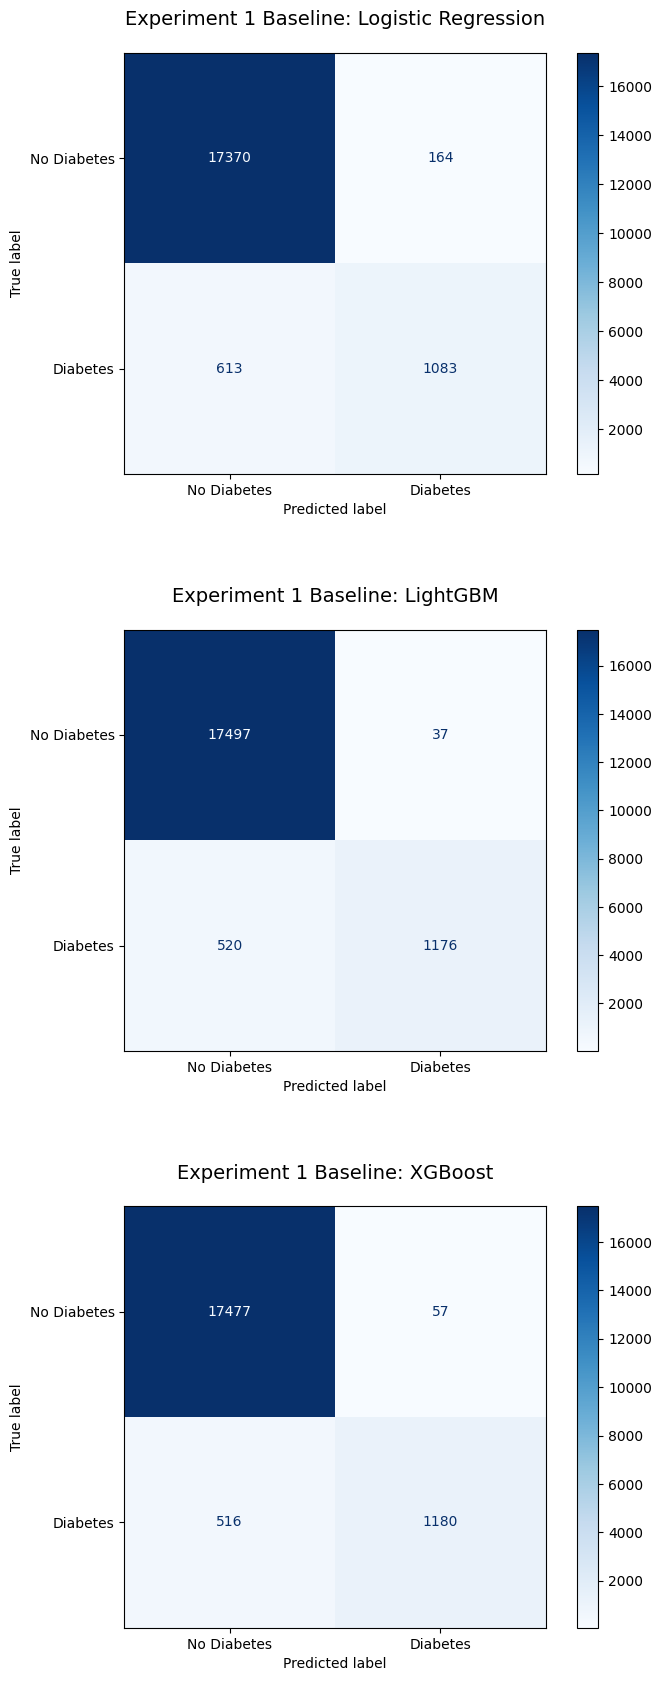

In [28]:
#confusion matrix grid
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

for i, (name, preds) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Diabetes', 'Diabetes']
    )

    disp.plot(ax=axes[i], cmap='Blues', colorbar=True)
    axes[i].set_title(f"Experiment 1 Baseline: {name}", fontsize=14, pad=20)

plt.tight_layout(pad=5.0)
plt.show()

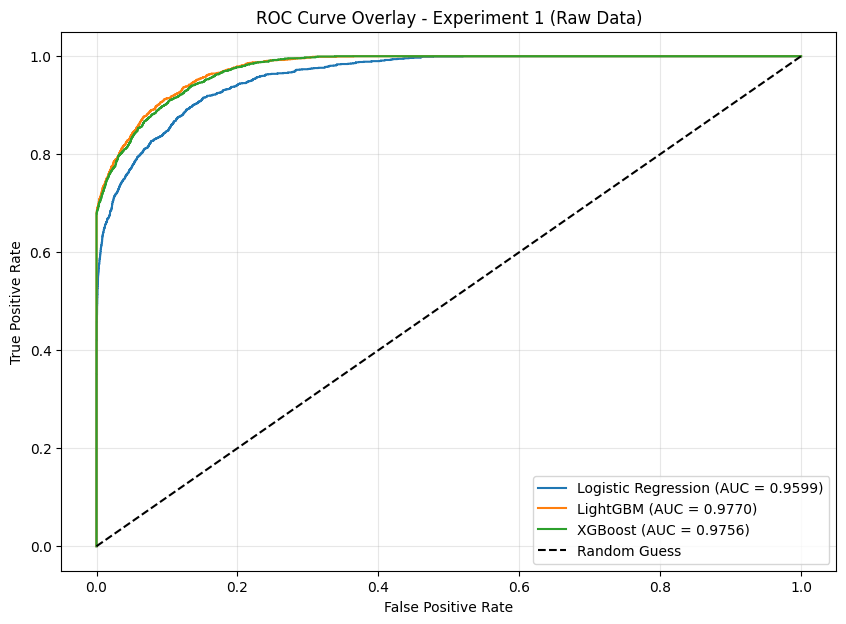

In [31]:
#roc curve
plt.figure(figsize=(10, 7))

for name, preds in model_preds.items():
    fpr, tpr, _ = roc_curve(y_test, preds['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Overlay - Experiment 1 (Raw Data)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

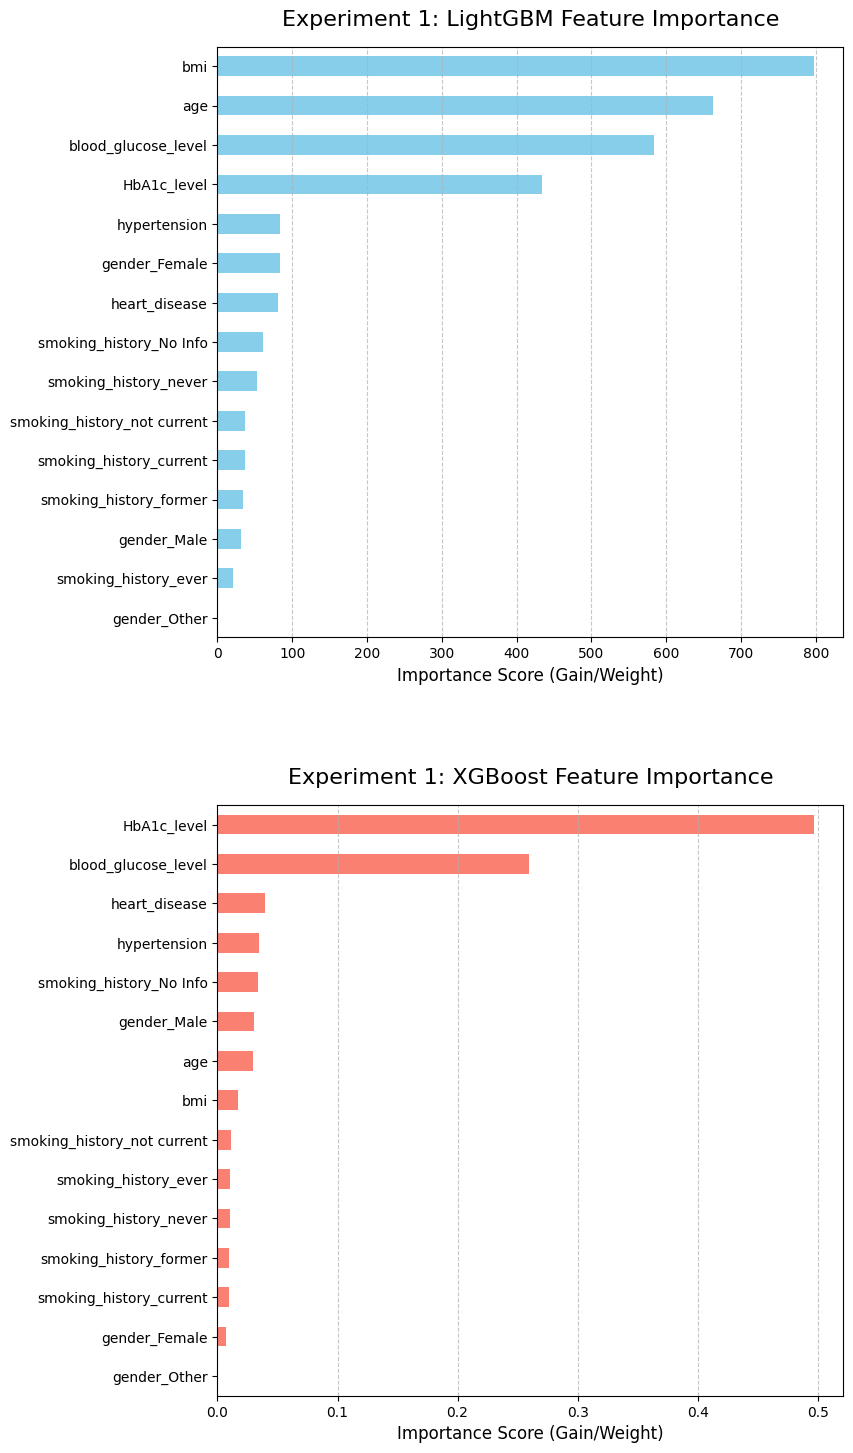

In [34]:
#feature importance lightgbm and xgboost

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 16))

#light gbm feature imporatance
lgbm_importances = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=True)
lgbm_importances.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title("Experiment 1: LightGBM Feature Importance", fontsize=16, pad=15)
ax1.set_xlabel("Importance Score (Gain/Weight)", fontsize=12)
ax1.grid(axis='x', linestyle='--', alpha=0.7)

#xgboost feature importance
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
xgb_importances.plot(kind='barh', ax=ax2, color='salmon')
ax2.set_title("Experiment 1: XGBoost Feature Importance", fontsize=16, pad=15)
ax2.set_xlabel("Importance Score (Gain/Weight)", fontsize=12)
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(pad=6.0)
plt.show()